In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from csv_reader import read_csv
from copy import deepcopy as copy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_PAIRWISE_RULES_PER_TYPE = 12 * 2
N_SUMMED_WEIGHT_RULES_PER_TYPE = 4
N_THREE_FACTOR_RULES_PER_TYPE = 8
N_RULES = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE) + 2 * N_THREE_FACTOR_RULES_PER_TYPE

CELL_TYPE_1_SIZE = 5

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS_NO_HET_SHORT = [
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244677_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244680_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244675_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244675_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244680_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:23.174955_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:23.174963_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:30.925336_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:03.672463_run_None',
]

DATA_PATHS_NO_HET_LONG = [
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:05.556906_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:15.419305_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:26.546887_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447171_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447169_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:26.630956_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:29.091066_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:29.091061_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447167_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:43.001674_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:42.975309_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:43.009313_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244672_run_None',
]

DATA_PATHS_NO_HET_SHORT_DROP_Z = [
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:40.453833_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:40.479882_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:39:37.864984_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:40:12.423111_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:40:36.158512_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:41:06.670440_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:41:37.489542_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:42:08.757776_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:42:39.625754_run_None',
]

DATA_PATHS_NO_HET_LONG_DROP_Z = [
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:32:01.722941_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:32:12.629517_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:07.546528_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:09.033664_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:03.666116_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:35:39.951326_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:35:39.951334_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168738_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168743_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168742_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:37:04.286858_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:05.257031_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:07.097905_run_None',
]

DATA_PATHS_NO_HET_SHORT_NO_PLASTICITY = [
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177461_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177466_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:24:21.115241_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:24:44.192562_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:24:44.006358_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:25:47.988878_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:25:49.675116_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:26:16.773122_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:26:16.191087_run_None',
]

DATA_PATHS_NO_HET_LONG_NO_PLASTICITY = [
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:19:48.576166_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:19:38.747591_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:19:38.762717_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:19:42.776157_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:20:49.751480_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:20:49.751483_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:20:50.710150_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:20:50.694646_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:22:46.830402_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177458_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177467_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177467_run_None',
    'sims_out/rule_dropout_no_plasticity_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_16:23:23.177468_run_None',
]



rules_to_dropout = np.concatenate([
    np.arange(N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
    np.arange(
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)
        + N_THREE_FACTOR_RULES_PER_TYPE,
    ),
])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'Const',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\Sigma_k w_{kj}$',
    r'$w \Sigma_k w_{kj}$',
	r'$\Sigma_k w_{ik}$',
    r'$w \Sigma_k w_{ik}$',
]

# rule_names = [
# 	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
# 	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
# 	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
# ]

rule_names = [
	rule_names,
    rule_names,
    rule_names,
]

rule_names_tripartite = [
	r'$\tilde{y} \tilde{z}$',
    r'$x \tilde{y} \tilde{z}$',
	r'$\tilde{x} \tilde{z}$',
	r'$\tilde{x} y \tilde{z}$',

	r'$w \tilde{y} \tilde{z}$',
    r'$w x \tilde{y} \tilde{z}$',
	r'$w \tilde{x} \tilde{z}$',
	r'$w \tilde{x} y \tilde{z}$',
]

rule_names += [
	[r_name for r_name in rule_names_tripartite],
	[r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)

In [7]:
print(rule_names)

['Const' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$' '$y^4$' '$x^4$'
 '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$' '$w$' '$w y$'
 '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$' '$w x^4$'
 '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$' '$\\Sigma_k w_{ik}$'
 '$w \\Sigma_k w_{ik}$' 'Const' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$'
 '$x^3$' '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$'
 '$\\tilde{x} \\, y$' '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$'
 '$w x^3$' '$w y^4$' '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$'
 '$w \\tilde{x} \\, y$' '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$'
 '$\\Sigma_k w_{ik}$' '$w \\Sigma_k w_{ik}$' 'Const' '$y$' '$x$' '$y^2$'
 '$x^2$' '$y^3$' '$x^3$' '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$'
 '$\\tilde{x} \\, y$' '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$'
 '$w x^3$' '$w y^4$' '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$'
 '$w \\tilde{x} \\, y$' '$\\Sigma_k w_{kj

In [8]:
def load_coefs(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)
    coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_RULES])
    return coefs

def load_all_coefs(dfs):
    return np.asarray([
        load_coefs(df)
        for df in dfs
    ])

def load_losses(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)

    losses = np.array(o.iloc[:, 1])
    return losses

def make_loss_plots(dfs, num_terms=36, vmax=500):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_losses(df)
        
        if len(losses) < 30 * (num_terms + 1):
            continue
            
        losses_for_term_dropouts = []
        for i in range(num_terms + 1):
            losses_for_term_dropouts.append(losses[30 * i: 30 * (i+1)])
        all_losses.append(losses_for_term_dropouts)

        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_losses = np.array(all_losses)
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(3, 1))
    for i in range(all_losses.shape[0]):
        axs.scatter([i] * 30, all_losses[i, 0, :], alpha=0.1)
        print(np.mean(all_losses[i, 0, :]), '+/-', np.std(all_losses[i, 0, :]))
    axs.set_ylim(0)
    axs.set_xlabel('Rule number')
    axs.set_ylabel('Loss')
    format_plot(axs)
    
    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    mat = (
        np.median(all_losses, axis=2)[:, 1:]
        - np.median(all_losses, axis=2)[:, 0][:, None]
    )
    
    sns.heatmap(
        mat.T,
        ax=ax,
        cmap='Blues',
        vmax=vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)

    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    all_coefs = all_coefs[:, rules_to_dropout]

    sns.heatmap(
        (mat * np.where(all_coefs > 0, 1, -1)).T,
        ax=ax,
        cmap=sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True),
        vmax=vmax,
        vmin=-vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )

    ctrl = np.median(all_losses, axis=2)[:, 0][:, None]

    counts_over_100 = np.where(mat > 100, 1, 0).sum(axis=1)
    print(np.mean(counts_over_100), np.std(counts_over_100))
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)

    ax.set_xticks([])

    ax.set_ylabel('Term dropped')
    ax.set_xlabel('Learned rule')
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)

    return fig, ax

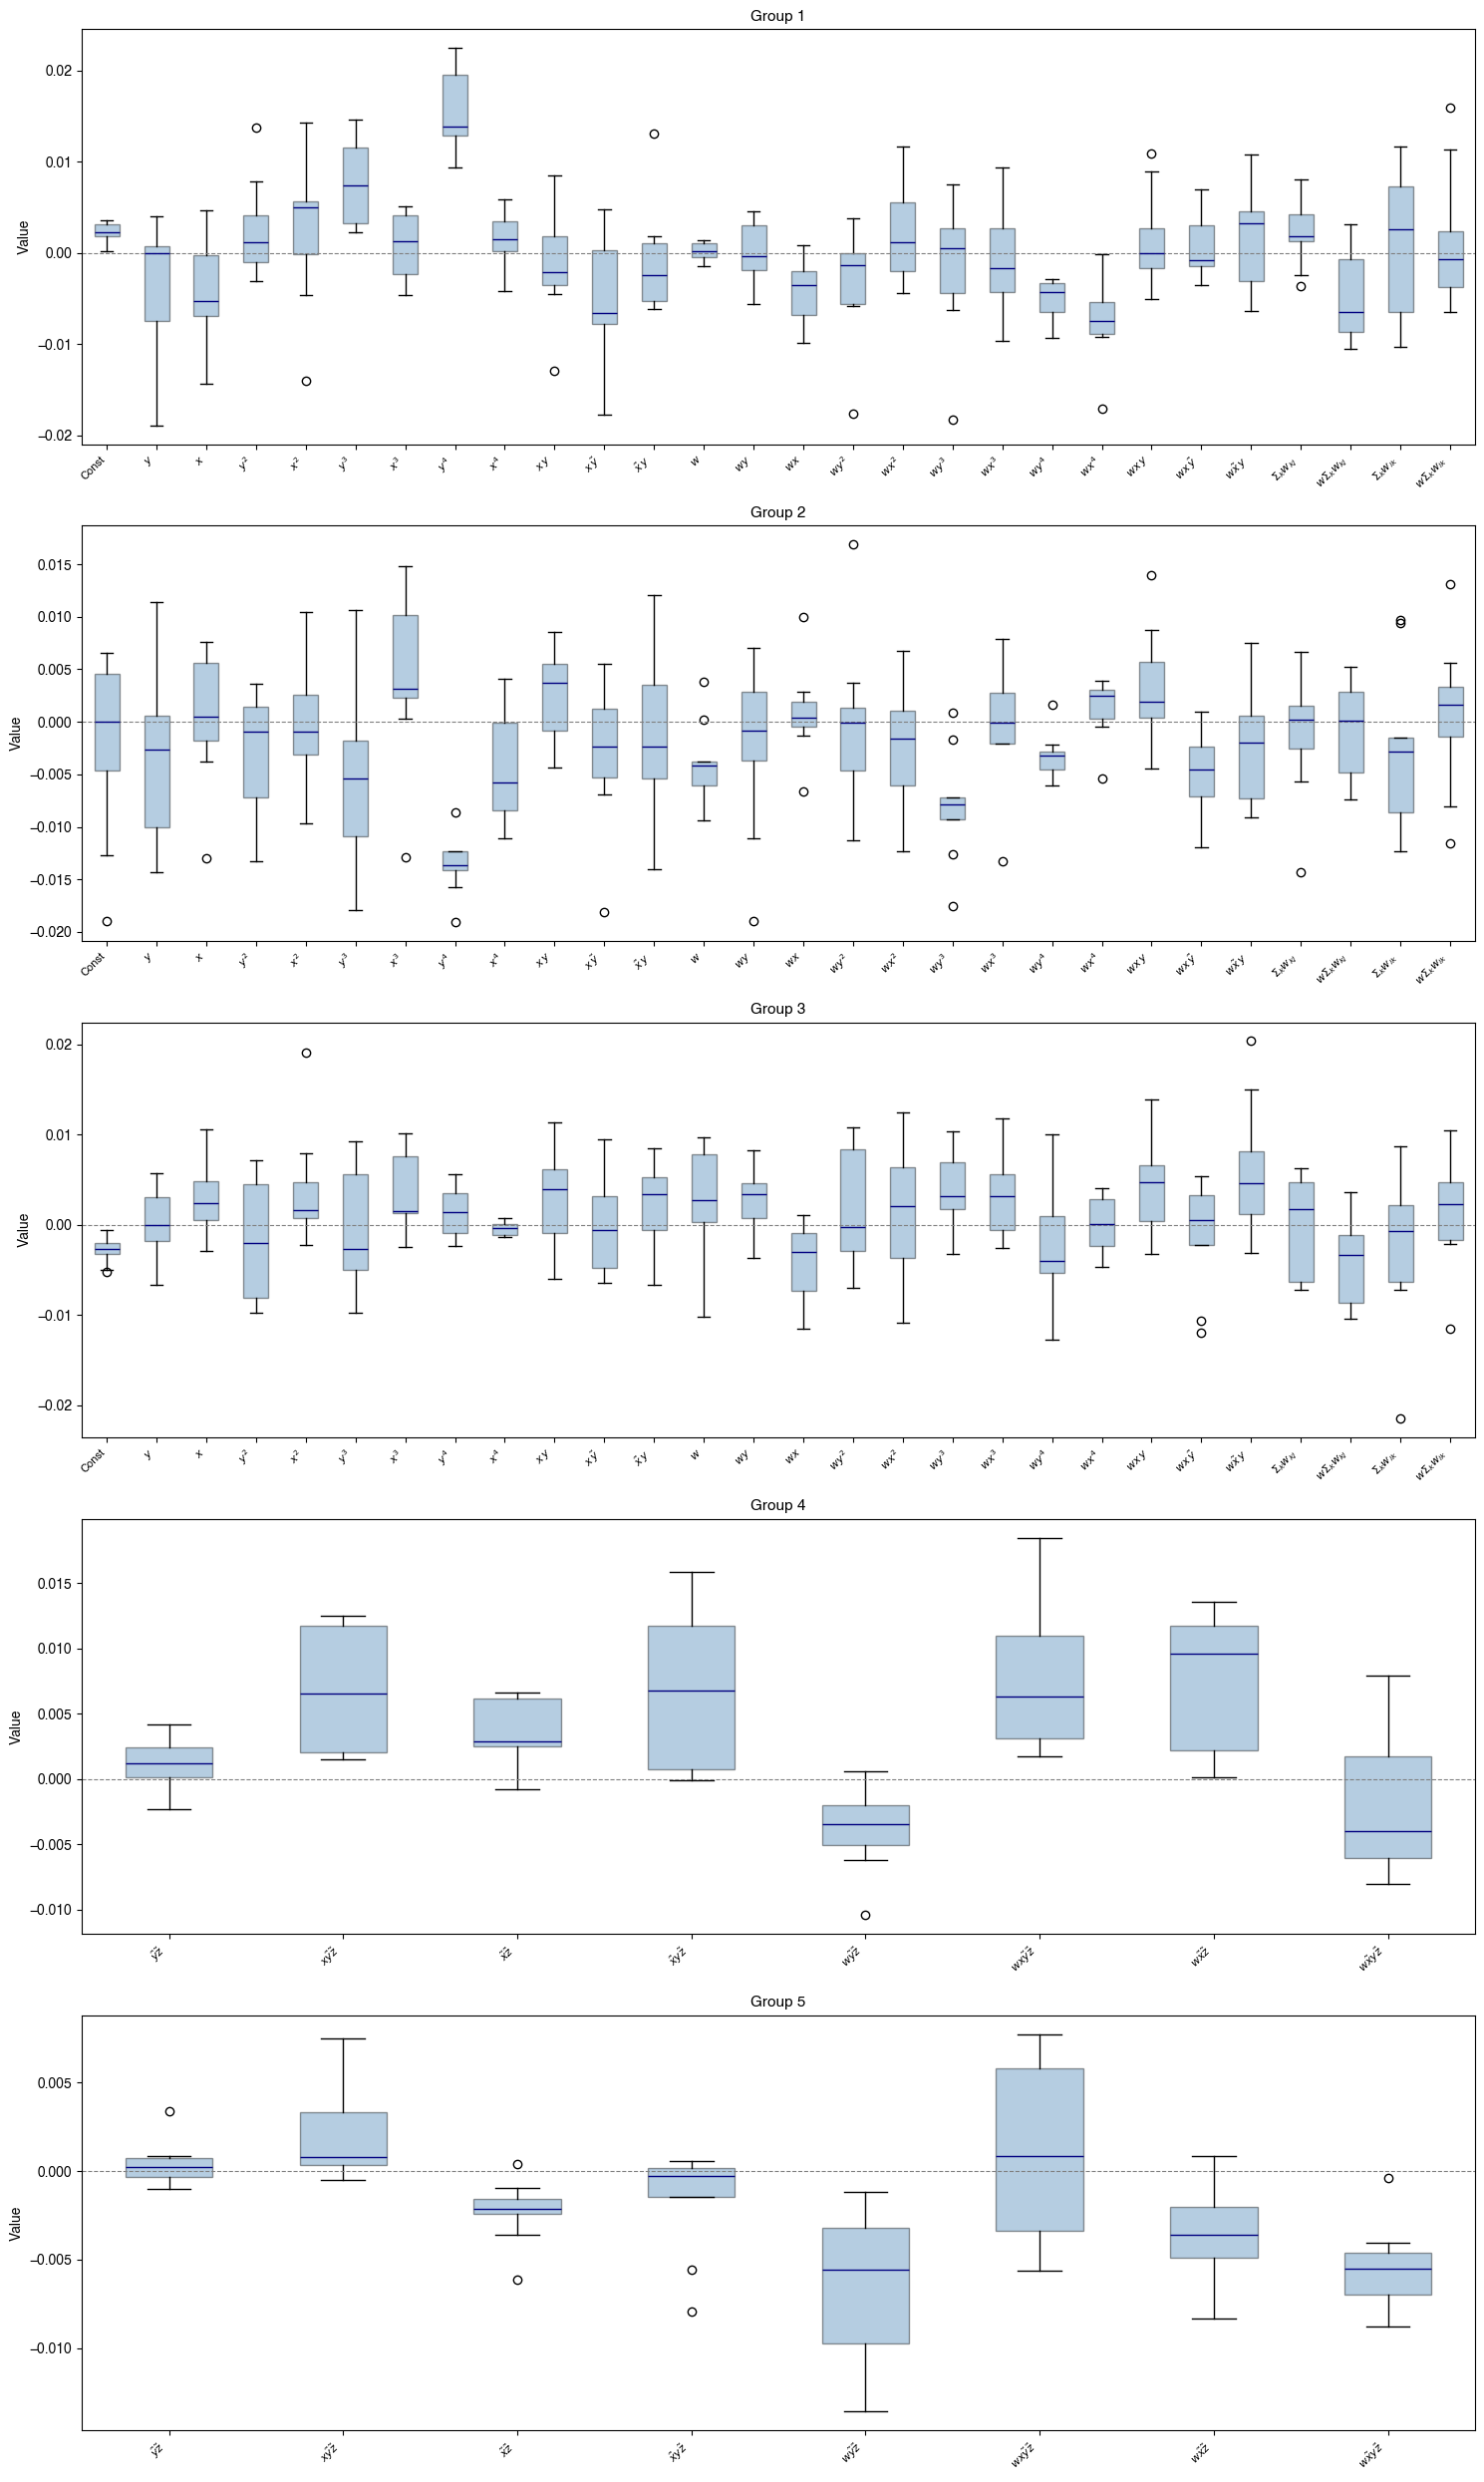

In [23]:
c = load_all_coefs(DATA_PATHS_NO_HET_SHORT)

groups = [
    (0,  28, "Group 1"),
    (28, 28, "Group 2"),
    (56, 28, "Group 3"),
    (84,  8, "Group 4"),
    (92,  8, "Group 5"),
]

scale = 5
fig, axs = plt.subplots(5, 1, figsize=(scale * 3, scale * 5))

for ax, (start, size, title) in zip(axs, groups):
    segment = c[:, start:start + size]
    labels = rule_names[start:start + size]

    ax.boxplot(segment, positions=np.arange(size), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.4),
               medianprops=dict(color='navy'))
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Value')
    ax.set_xticks(np.arange(size))
    ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')

plt.tight_layout()
plt.show()

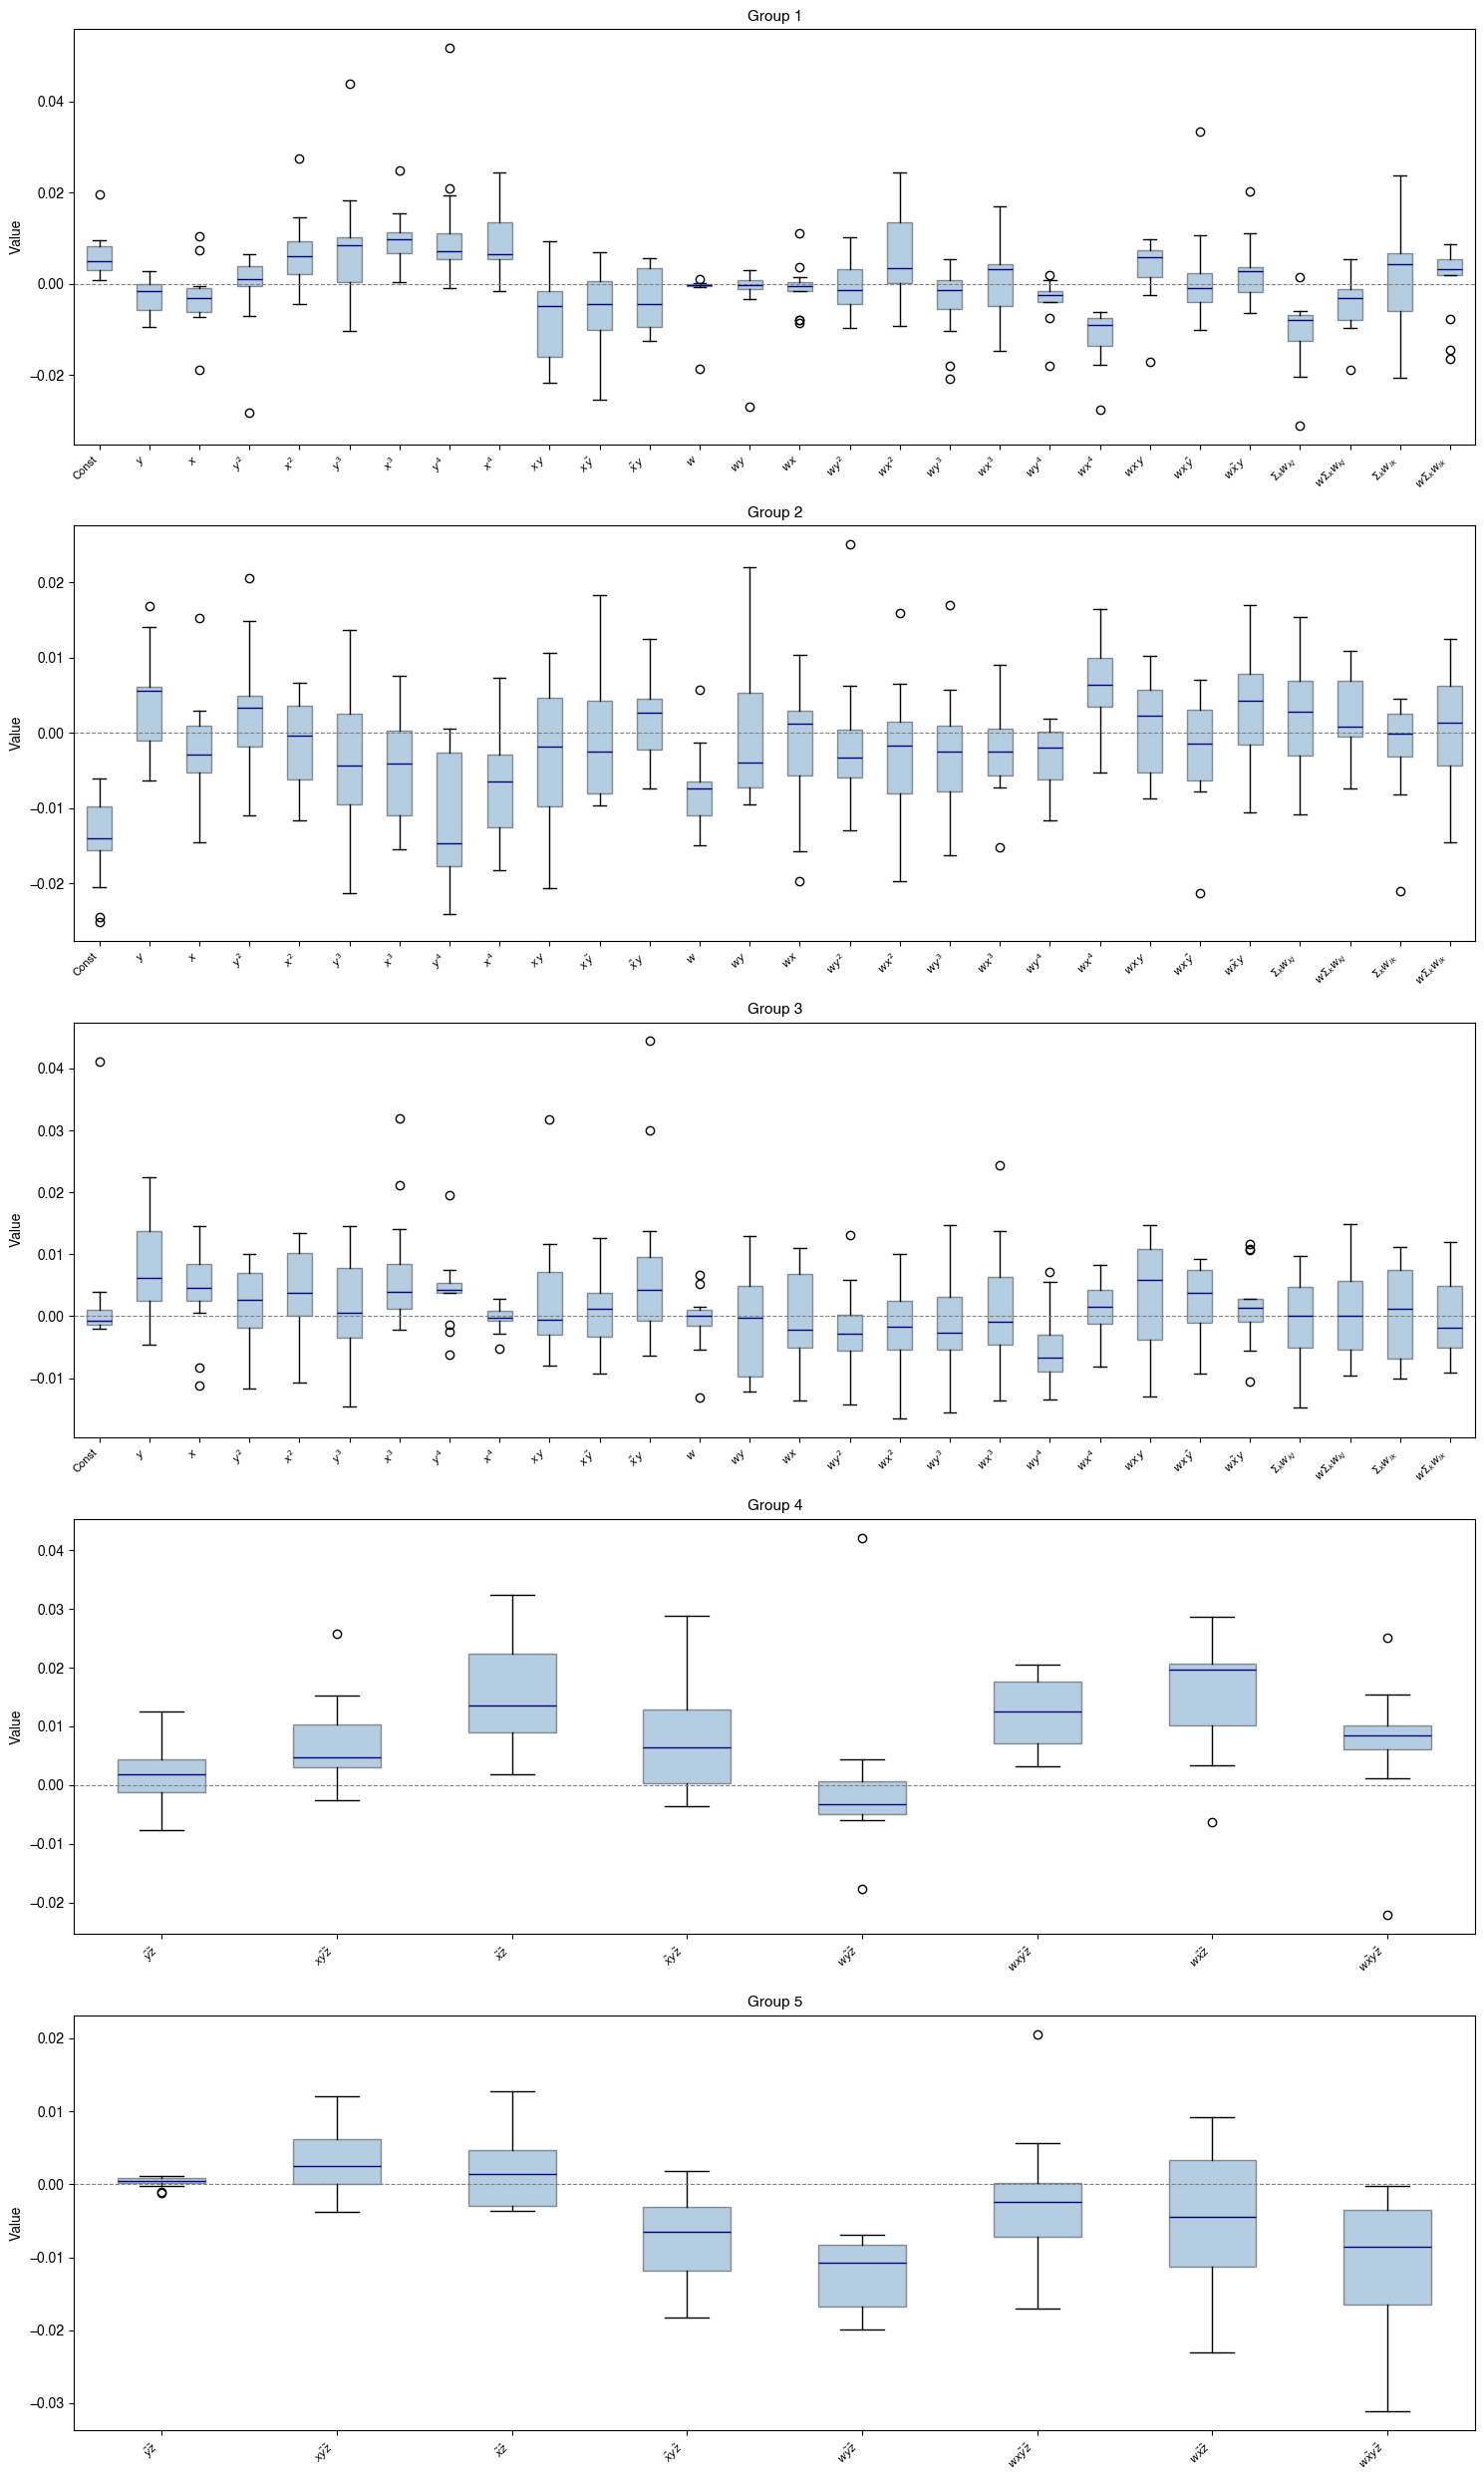

In [24]:
c = load_all_coefs(DATA_PATHS_NO_HET_LONG)

groups = [
    (0,  28, "Group 1"),
    (28, 28, "Group 2"),
    (56, 28, "Group 3"),
    (84,  8, "Group 4"),
    (92,  8, "Group 5"),
]

scale = 5
fig, axs = plt.subplots(5, 1, figsize=(scale * 3, scale * 5))

for ax, (start, size, title) in zip(axs, groups):
    segment = c[:, start:start + size]
    labels = rule_names[start:start + size]

    ax.boxplot(segment, positions=np.arange(size), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.4),
               medianprops=dict(color='navy'))
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Value')
    ax.set_xticks(np.arange(size))
    ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')

plt.tight_layout()
plt.show()

169.41478501120233 +/- 33.899553979963954
182.55851300423032 +/- 27.43466945891271
165.90221611869475 +/- 42.15347544991641
161.1864405474992 +/- 21.362095307110216
177.41095224160844 +/- 24.854818643511912
185.5084898996929 +/- 29.884535064996722
169.39874793395427 +/- 28.307200915827202
176.12258627622714 +/- 40.34780019775717
176.11855313473617 +/- 25.226008860191314
11.444444444444445 3.095197394929804


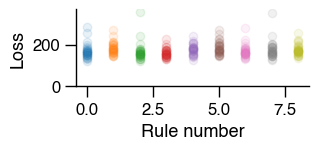

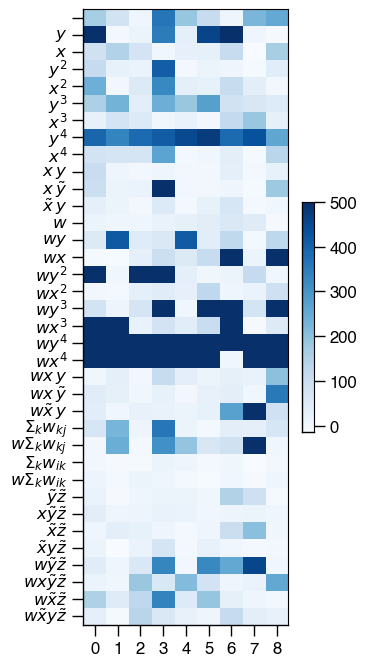

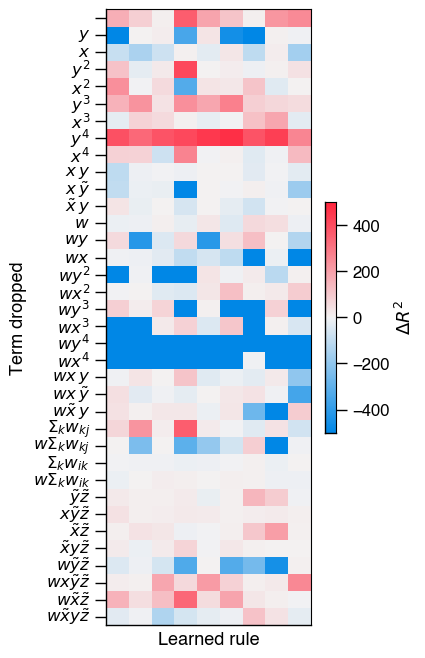

In [28]:
fig, ax = make_loss_plots(DATA_PATHS_NO_HET_SHORT, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_short.svg')

243.60275758139088 +/- 32.19805263226764
235.73006506023856 +/- 39.6180252158584
220.62005230944845 +/- 35.49392169608082
219.42391111797056 +/- 51.85952094361473
229.02544935911115 +/- 40.15481376574529
226.49412033933797 +/- 37.748967804140136
234.8703408888063 +/- 39.678599136731435
220.27001406495714 +/- 34.84754564187452
239.4556196157201 +/- 42.18354184198734
249.4498436918451 +/- 37.02183309633702
215.84346275935883 +/- 32.745765448056815
236.96619732346866 +/- 33.2165615691795
133.29618342778593 +/- 15.687916559685917
14.846153846153847 2.6266724736867495


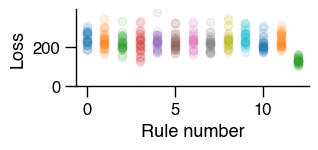

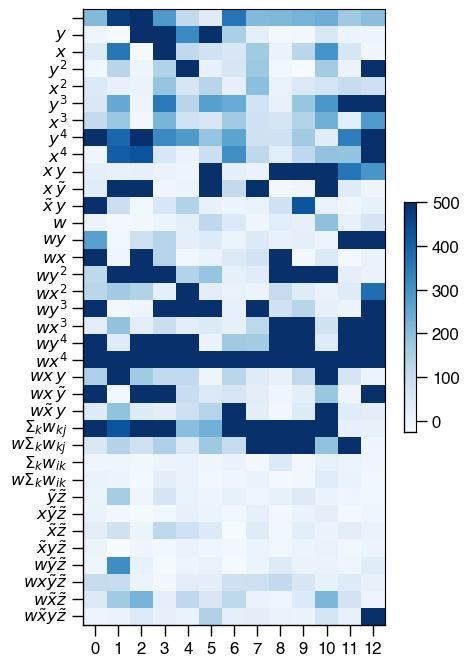

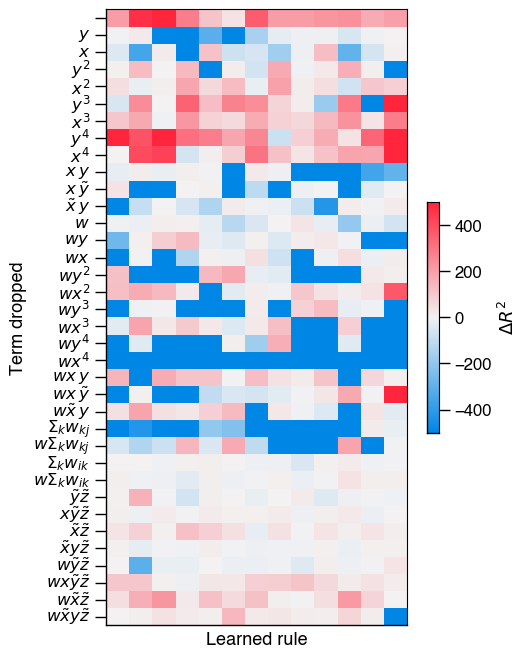

In [29]:
fig, ax = make_loss_plots(DATA_PATHS_NO_HET_LONG, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_long.svg')

In [7]:
def load_r2(df, n_nets=30):
    rule_path = Path(df) / 'scores'
    arrays = []
    arr = np.array([np.load(f) for f in rule_path.glob('ctrl/*.npy')])
    arrays.append(arr)
    for dropout_num in rules_to_dropout:
        d = zero_pad(dropout_num, 3)
        arr = np.array([np.load(f) for f in rule_path.glob(f'{d}/*.npy')])
        if len(arr) < n_nets:
            arr = np.concatenate([
                arr,
                np.zeros(n_nets - len(arr))
            ])
        arrays.append(arr)
    return arrays


def make_r2_plots(dfs, num_terms=36, vmax=1, save_name=None):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_r2(df)
        all_losses.append(losses)
        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(3, 1))
    for i in range(len(all_losses)):
        ctrl_losses_for_rule = all_losses[i][0]
        axs.scatter([i] * len(ctrl_losses_for_rule), ctrl_losses_for_rule, alpha=0.3, facecolor='none', edgecolor='black', s=40)
        print(np.mean(ctrl_losses_for_rule), '+/-', np.std(ctrl_losses_for_rule))
    axs.set_ylim(0, 1)
    axs.set_xlabel('Rule number')
    axs.set_ylabel(r'$R^2$')
    axs.xaxis.set_major_locator(MaxNLocator(integer=True))
    format_plot(axs)
    
    fig, ax = plt.subplots(1, 1, figsize=(0.33 * len(all_losses), 8))

    losses_medians = np.array([
        [np.median(term_losses) for term_losses in rule_losses]
        for rule_losses in all_losses
    ])

    mat = (
        losses_medians[:, 1:] - losses_medians[:, :1]
    )
    
    sns.heatmap(
        mat.T,
        ax=ax,
        cmap='Blues_r',
        vmax=0,
        vmin=-0.85,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / mat.shape[0], pad=0.06),
        
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)

    ax.set_ylabel('Term dropped')
    ax.set_xlabel('Learned rule')

    ax.collections[0].colorbar.set_label(r'$\Delta R^2$')

    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)

    if save_name is not None:
        fig.savefig(save_name + '_r2_heatmap.svg')
    
    fig_r2_change_scatter, axs_r2_change_scatter = plt.subplots(1, 1, figsize=(6 * 2, 1 * 2))
    for j in range(mat.shape[1]):
         axs_r2_change_scatter.scatter([j] * mat.shape[0] , mat[:, j], alpha=0.4, facecolor='none', edgecolor='#c9294c', s=40)
    axs_r2_change_scatter.set_xticks(np.arange(num_terms))
    axs_r2_change_scatter.set_xticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=40)
    axs_r2_change_scatter.set_ylabel(r'$\Delta R^2$')
    axs_r2_change_scatter.set_xlabel('Term dropped')
    axs_r2_change_scatter.axhline(0, color='black', zorder=-1, alpha=0.3)
    axs_r2_change_scatter.set_xlim(-0.5, num_terms - 0.5)
    format_plot(axs_r2_change_scatter)

    if save_name is not None:
        fig_r2_change_scatter.savefig(save_name + '_r2_scatter.svg')

    fig, ax = plt.subplots(1, 1, figsize=(0.33 * mat.shape[0], 8))

    all_coefs = all_coefs[:, rules_to_dropout]

    sns.heatmap(
        (np.abs(mat) * np.where(all_coefs > 0, 1, -1)).T,
        ax=ax,
        cmap=sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True),
        vmax=vmax,
        vmin=-vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / mat.shape[0], pad=0.06),
    )

    ctrl = losses_medians[:, :1]

    counts_over_100 = np.where(mat < -0.1, 1, 0).sum(axis=1)
    print(np.mean(counts_over_100), np.std(counts_over_100))
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)

    ax.set_xticks([])

    ax.set_ylabel('Term dropped')
    ax.set_xlabel('Learned rule')

    ax.collections[0].colorbar.set_label(r'$\rm{Sign}(c)\, |\Delta R^2$|')
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)   

    if save_name is not None:
        fig.savefig(save_name + '_r2_signed_heatmap.svg')

    return fig, ax

0.837182730298648 +/- 0.03479976468992772
0.82435695518489 +/- 0.028521802637486916
0.8400820944308028 +/- 0.042670105902560505
0.8459024463562239 +/- 0.02154769046033354
0.8288292741612703 +/- 0.02506637379795866
0.820525650012634 +/- 0.02990089626305565
0.8367744604298968 +/- 0.02795469874594869
0.8304407968599657 +/- 0.04115288983538924
0.8292987843732669 +/- 0.025425704116006215
11.444444444444445 3.095197394929804


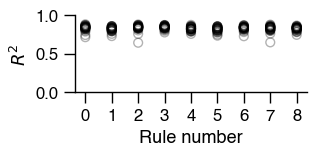

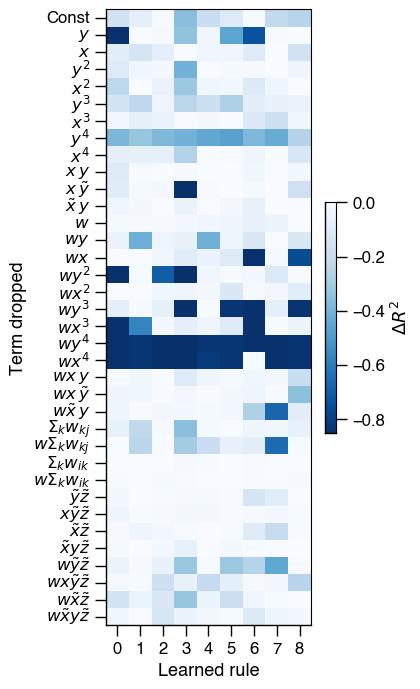

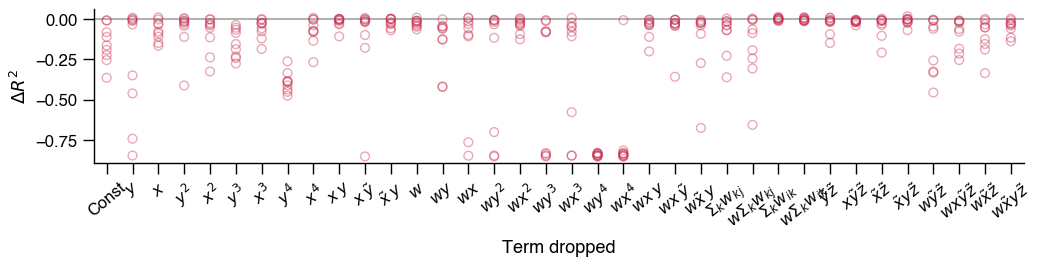

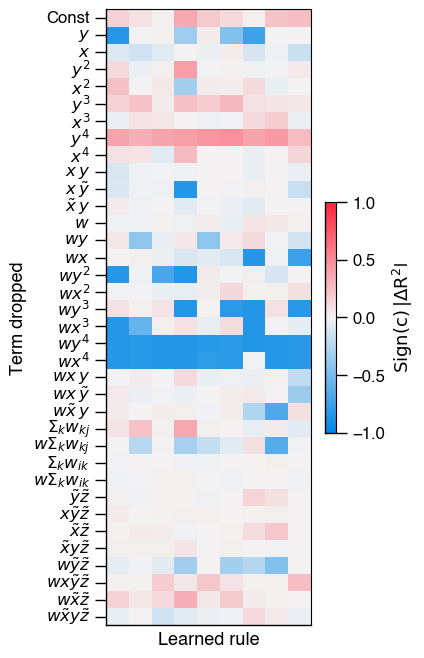

In [8]:
fig, ax = make_r2_plots(DATA_PATHS_NO_HET_SHORT, num_terms=36, save_name='./figures/rule_dropouts_n5_short')

0.7597902135806105 +/- 0.032267323449830125
0.7681430358463718 +/- 0.03979251113291399
0.7825744371874979 +/- 0.035562285232610326
0.7829239270185833 +/- 0.051898624919089906
0.7737670718514004 +/- 0.04005173076742025
0.7762083629113594 +/- 0.03780989494734224
0.7681959814696432 +/- 0.03980494048133533
0.7820368617957338 +/- 0.03483478165645492
0.7635411842123604 +/- 0.042019883008830236
0.7530590100069252 +/- 0.03704935156797584
0.7867636327136526 +/- 0.03269874120724726
0.766120068755083 +/- 0.03312845737540018
14.833333333333334 2.733536577809454


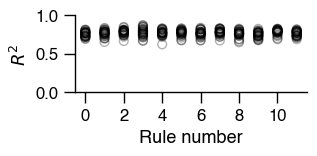

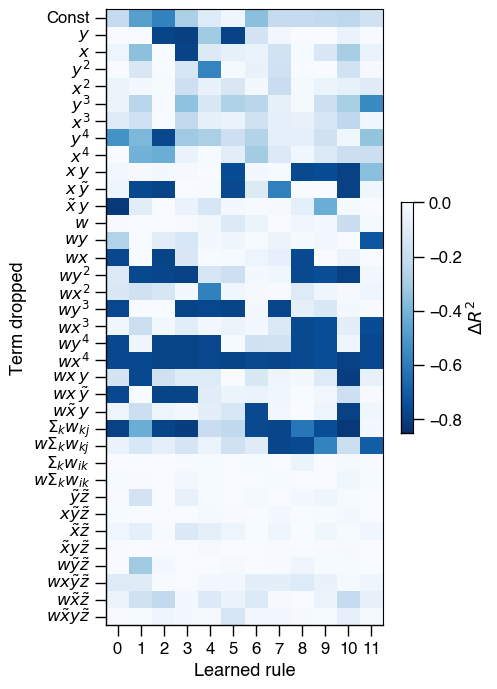

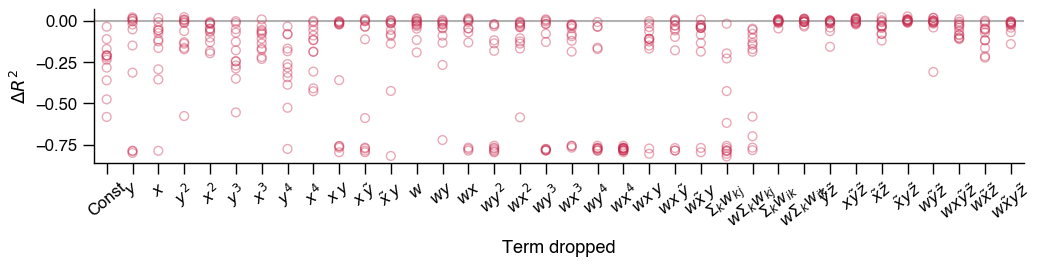

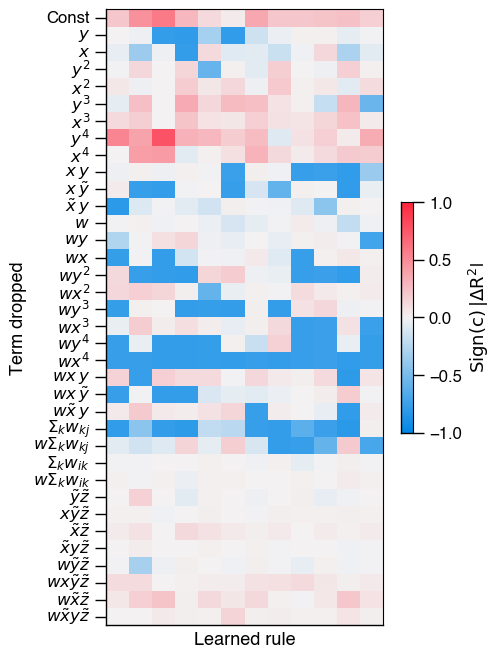

In [9]:
fig, ax = make_r2_plots(DATA_PATHS_NO_HET_LONG[:-1], num_terms=36, save_name='./figures/rule_dropouts_n5_long')

In [6]:
def load_r2_specific_groups(df, groups, n_nets=30):
    rule_path = Path(df) / 'scores'
    arrays = []
    for group in groups:
        arr = np.array([np.load(f) for f in rule_path.glob(f'{group}/*.npy')])
        if len(arr) < n_nets:
            arr = np.concatenate([
                arr,
                np.zeros(n_nets - len(arr))
            ])
        arrays.append(arr)
    return arrays


def make_r2_plots_drop_specific_groups(dfs, groups, colors=['black', 'red'], vmax=1, vmin=-0.3):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_r2_specific_groups(df, groups)
        all_losses.append(losses)
        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(4, 1))
    for i in range(len(all_losses)):
        ctrl_losses_for_rule = all_losses[i][0]
        axs.scatter([i -0.15] * len(ctrl_losses_for_rule), ctrl_losses_for_rule, alpha=0.3, facecolor='none', edgecolor=colors[0], s=40)
        z_losses_for_rule = all_losses[i][1]
        axs.scatter([i + 0.15] * len(z_losses_for_rule), z_losses_for_rule, alpha=0.3, facecolor='none', edgecolor=colors[1], s=40)

        print(ctrl_losses_for_rule.mean(), '+/-', ctrl_losses_for_rule.std())
        print(z_losses_for_rule.mean(), '+/-', z_losses_for_rule.std())
        print('')

    axs.set_ylim(vmin, vmax)
    axs.set_xlabel('Rule number')
    axs.set_ylabel(r'$R^2$')
    axs.xaxis.set_major_locator(MaxNLocator(integer=True))
    format_plot(axs)
    return fig, axs

0.7641606421652365 +/- 0.03062003503963933
-0.020583676563859375 +/- 0.045150238488117465

0.7830024527073812 +/- 0.0358851443712688
-0.03258409351157747 +/- 0.04312514382795766

0.7894922791240255 +/- 0.02801703664929877
-0.017612518669696008 +/- 0.033602458659098416

0.7646128074548438 +/- 0.10402845693512505
-0.024262579443006995 +/- 0.044775081936159415

0.7555696877758046 +/- 0.031254388930730674
-0.025006754885911187 +/- 0.037192189963172945

0.7742521865330728 +/- 0.035353933449926364
-0.02012897564981506 +/- 0.0275600854991441

0.7896837294288205 +/- 0.030458541234862524
-0.02101685467968002 +/- 0.04490689429029313

0.7792233532109621 +/- 0.0496293855397934
-0.005951300045189812 +/- 0.029548061221988612

0.7820366881808652 +/- 0.034020338712082245
-0.023621916059176552 +/- 0.03033698171875317

0.7528949689404275 +/- 0.04150168247634969
-0.01749900437057165 +/- 0.033321089276148255

0.7929136964095818 +/- 0.03272533640971629
-0.03361443896657835 +/- 0.05289180802053028

0.783023

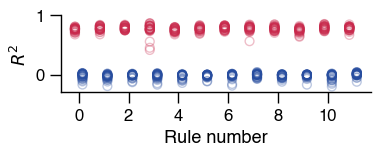

In [9]:
fig, ax = make_r2_plots_drop_specific_groups(DATA_PATHS_NO_HET_LONG_DROP_Z[:-1], ['ctrl', 'z'], colors=['#c9294c', '#274d9f'])
fig.savefig('./figures/rule_dropouts_n5_z_long_r2.svg')

0.8378505100026179 +/- 0.020756797837602637
0.0852169445087096 +/- 0.09171251146946242

0.8230894374083078 +/- 0.03797973288150993
0.17621984353558637 +/- 0.053886681544615005

0.8351078711748621 +/- 0.02248305778094199
0.0582496393181622 +/- 0.10146421103925829

0.8364318429726451 +/- 0.02684525275218195
0.1084877683628096 +/- 0.07247709320358293

0.8243818211787256 +/- 0.026033319591982945
0.2132729873923558 +/- 0.06787745740182

0.8338815934343405 +/- 0.018769658355200343
0.257071250252309 +/- 0.07765866086070664

0.8294005047360785 +/- 0.032893327570512526
0.2167320534244344 +/- 0.06627831351304239

0.8451850677292126 +/- 0.027070324326814704
0.2090810462153697 +/- 0.05758735010216677

0.8422513266644565 +/- 0.02886215171905325
0.1970501098968275 +/- 0.047107805799909315



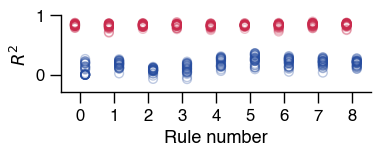

In [10]:
fig, ax = make_r2_plots_drop_specific_groups(DATA_PATHS_NO_HET_SHORT_DROP_Z, ['ctrl', 'z'], colors=['#c9294c', '#274d9f'])
fig.savefig('./figures/rule_dropouts_z_n5_long_r2.svg')

0.764716444164177 +/- 0.03281466916798336
-0.03266376178129165 +/- 0.04573683432346665

0.7883591035221273 +/- 0.0269716731174733
-0.029325874938831556 +/- 0.02910545166466849

0.7890292241528232 +/- 0.03452267545672527
-0.03275391517465524 +/- 0.04738479877752139

0.7837092002839968 +/- 0.050344684138011235
-0.020777271127765572 +/- 0.02920580170597458

0.7698041590631634 +/- 0.038773901172559126
-0.01679484052659067 +/- 0.018873493017385383

0.7687955545768131 +/- 0.02766202441854766
-0.026178523320496024 +/- 0.04188880547524266

0.7670535107525982 +/- 0.042624721449292684
-0.028561258166412033 +/- 0.052761906501981606

0.7741887030255865 +/- 0.037364209086017
-0.014582042369670962 +/- 0.0202446704664018

0.762046481065602 +/- 0.056842305067669796
-0.027747240030433214 +/- 0.03693391296018846

0.7578326260403414 +/- 0.029429663858577336
-0.03625011693280887 +/- 0.03990206573732729

0.7698317511119854 +/- 0.03933952422851944
-0.026140923647640948 +/- 0.025900242350115628

0.7751072751

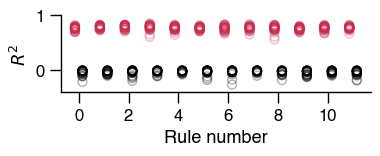

In [11]:
fig, ax = make_r2_plots_drop_specific_groups(DATA_PATHS_NO_HET_LONG_NO_PLASTICITY[:-1], ['ctrl', 'no_plasticity'], ['#c9294c', 'black'], vmin=-0.4)
fig.savefig('./figures/rule_dropouts_n5_no_plasticity_long_r2.svg')

0.8369875719379795 +/- 0.030471711876529164
-0.027431671187832147 +/- 0.0403188676006361

0.8351067820886691 +/- 0.03247437007089643
-0.03309392494632612 +/- 0.04150038022264917

0.849226813571482 +/- 0.01861294668428112
-0.016997622337091404 +/- 0.020004875479454853

0.8440413437540115 +/- 0.025941279654606138
-0.02427006022025197 +/- 0.04839556896600999

0.8328154182786454 +/- 0.03217466535068091
-0.02287793166712649 +/- 0.02749110139097409

0.825532345297155 +/- 0.021187189349452077
-0.010434950121633535 +/- 0.011953634409942699

0.8305985548778907 +/- 0.028494475520786284
-0.01809050129604696 +/- 0.0179827591736078

0.8430524111158129 +/- 0.03205393931587238
-0.018600169756353323 +/- 0.027750882363038923

0.8291231966338333 +/- 0.03004088116810187
-0.019673139595716222 +/- 0.030243378935426193



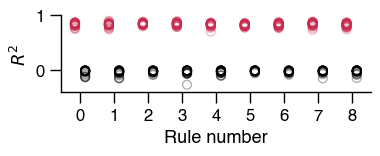

In [12]:
fig, ax = make_r2_plots_drop_specific_groups(DATA_PATHS_NO_HET_SHORT_NO_PLASTICITY, ['ctrl', 'no_plasticity'], colors=['#c9294c', 'black'], vmin=-0.4)
fig.savefig('./figures/rule_dropouts_n5_no_plasticity_short_r2.svg')